In [2]:
import matplotlib as mpl

mpl.rcParams["animation.ffmpeg_path"] = (
    r"C:\Users\z0059atu\AppData\Local\Microsoft\WinGet\Packages"
    r"\Gyan.FFmpeg_Microsoft.Winget.Source_8wekyb3d8bbwe"
    r"\ffmpeg-8.1.2-full_build\bin\ffmpeg.exe"
)

In [6]:
"""
2D wave equation solver
=======================
    u_tt = c^2 (u_xx + u_yy),   (x,y) in [0,1]^2,   u = 0 on the boundary

First-order form:
    u_t = v
    v_t = c^2 * L u                 (L = discrete Laplacian)

so with Y = [u, v]^T we have the *linear* system  F(Y) = A Y  with

    A = [[ 0      I ],
         [ c^2 L  0 ]]

Time integration: Crank-Nicolson (trapezoidal rule, 2nd order, A-stable)

    (I - dt/2 A) Y_{n+1} = (I + dt/2 A) Y_n

The amplification factor is the Cayley transform (1 + z/2)/(1 - z/2), whose
modulus is exactly 1 for z on the imaginary axis.  The semi-discrete wave
operator A has purely imaginary spectrum, so the scheme neither damps nor
amplifies any mode: the discrete energy is conserved and there is no CFL
restriction on dt (accuracy, not stability, sets the step size).

The system matrix is constant, so it is assembled and LU-factorized once.
"""

import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers '3d' projection)


# ----------------------------------------------------------------------
# Grid
# ----------------------------------------------------------------------
def create_grid(N=201):
    """
    Uniform N x N grid on [0,1]^2 including boundary nodes.

    Only the (N-2)^2 *interior* nodes are unknowns: Dirichlet u = 0 is
    imposed strongly by simply never storing / updating boundary values.
    """
    x = np.linspace(0.0, 1.0, N)
    y = np.linspace(0.0, 1.0, N)
    h = x[1] - x[0]
    X, Y = np.meshgrid(x, y, indexing="ij")
    return x, y, X, Y, h


# ----------------------------------------------------------------------
# Discrete Laplacian
# ----------------------------------------------------------------------
def laplacian(N, h):
    """
    Second-order central-difference Laplacian on the interior nodes,
    built by Kronecker sums of the 1D operator

        D2 = (1/h^2) tridiag(1, -2, 1)

    The Dirichlet ghost contributions vanish (u = 0), so no extra terms
    appear on the right-hand side.

        L = D2 (x) I  +  I (x) D2      ("(x)" = Kronecker product)

    Returns an (m^2 x m^2) CSR matrix with m = N-2, using 'ij' (row-major
    over x) ordering consistent with the meshgrid above.
    """
    m = N - 2
    e = np.ones(m)
    D2 = sp.diags([e[:-1], -2.0 * e, e[:-1]], [-1, 0, 1], format="csr") / h**2
    I = sp.identity(m, format="csr")
    return sp.kron(D2, I, format="csr") + sp.kron(I, D2, format="csr")


def build_A(L, c):
    """
    Block operator of the first-order system:

        A = [[ 0      I ],
             [ c^2 L  0 ]]
    """
    n = L.shape[0]
    Z = sp.csr_matrix((n, n))
    I = sp.identity(n, format="csr")
    return sp.bmat([[Z, I], [c**2 * L, Z]], format="csr")


# ----------------------------------------------------------------------
# Initial condition
# ----------------------------------------------------------------------
def initialize_condition(X, Y):
    """
    Gaussian bump displacement, zero initial velocity:

        u(x,y,0) = exp(-100((x-0.5)^2 + (y-0.5)^2)),   v(x,y,0) = 0
    """
    u0 = np.exp(-100.0 * ((X - 0.5) ** 2 + (Y - 0.5) ** 2))
    u0[0, :] = u0[-1, :] = u0[:, 0] = u0[:, -1] = 0.0   # strong BC
    v0 = np.zeros_like(u0)
    return u0, v0


def to_interior(field):
    """Flatten the interior of a 2D field to a vector of unknowns."""
    return field[1:-1, 1:-1].ravel()


def to_field(vec, N):
    """Inverse of `to_interior`: rebuild the full field, boundary = 0."""
    f = np.zeros((N, N))
    f[1:-1, 1:-1] = vec.reshape(N - 2, N - 2)
    return f


# ----------------------------------------------------------------------
# Crank-Nicolson operators
# ----------------------------------------------------------------------
def build_cn_operators(A, dt):
    """
    Assemble and factorize the time-invariant Crank-Nicolson operators.

        LHS = I - dt/2 A      (LU-factorized once, reused every step)
        RHS = I + dt/2 A

    Returns (solve, RHS) where `solve(b)` applies LHS^{-1}.
    """
    n = A.shape[0]
    I = sp.identity(n, format="csr")
    LHS = (I - 0.5 * dt * A).tocsc()
    RHS = (I + 0.5 * dt * A).tocsr()
    return spla.factorized(LHS), RHS


def crank_nicolson_step(Yn, solve, RHS):
    """One trapezoidal step: Y_{n+1} = LHS^{-1} (RHS Y_n)."""
    return solve(RHS @ Yn)


# ----------------------------------------------------------------------
# Discrete energy (conserved invariant, used for verification)
# ----------------------------------------------------------------------
def energy(Y, L, c):
    """
    E = 1/2 ( ||v||^2 - c^2 u^T L u ).

    -L is symmetric positive definite, so E >= 0 and is exactly conserved
    by the trapezoidal rule in exact arithmetic.
    """
    n = Y.size // 2
    u, v = Y[:n], Y[n:]
    return 0.5 * (v @ v - c**2 * (u @ (L @ u)))


# ----------------------------------------------------------------------
# Driver
# ----------------------------------------------------------------------
def simulate(N=201, c=1.0, T=1.5, cfl=0.4, store_every=4):
    x, y, X, Y, h = create_grid(N)
    dt = cfl * h / c          # accuracy-driven; CN has no stability limit
    nsteps = int(round(T / dt))

    L = laplacian(N, h)
    A = build_A(L, c)
    n = A.shape[0]

    # --- constant CN operators: assemble + factorize once --------------
    solve, RHS = build_cn_operators(A, dt)

    u0, v0 = initialize_condition(X, Y)
    Yn = np.concatenate([to_interior(u0), to_interior(v0)])

    E0 = energy(Yn, L, c)
    max_drift = 0.0

    frames = [to_field(Yn[: n // 2], N)]
    times = [0.0]

    for step in range(1, nsteps + 1):
        Yn = crank_nicolson_step(Yn, solve, RHS)
        max_drift = max(max_drift, abs(energy(Yn, L, c) - E0))
        if step % store_every == 0:
            frames.append(to_field(Yn[: n // 2], N))
            times.append(step * dt)

    print(f"N={N}, dt={dt:.5f}, steps={nsteps}, frames={len(frames)}")
    print(f"relative energy drift over run: {max_drift / E0:.2e}")
    return X, Y, frames, times

In [ ]:


# # ----------------------------------------------------------------------
# # Animation
# # ----------------------------------------------------------------------
# def animate_solution(X, Y, frames, times, filename="wave_carpet.mp4",
#                      stride=2, fps=30):
#     """
#     3D surface animation ("moving carpet") with displacement-based colours
#     and a slowly rotating camera.
#     """
#     Xs, Ys = X[::stride, ::stride], Y[::stride, ::stride]
#     zmax = max(0.6 * np.abs(frames[0]).max(), 1e-6)

#     fig = plt.figure(figsize=(9, 7))
#     ax = fig.add_subplot(111, projection="3d")
#     fig.patch.set_facecolor("black")
#     ax.set_facecolor("black")

#     norm = plt.Normalize(-zmax, zmax)

#     def draw(k):
#         ax.clear()
#         Z = frames[k][::stride, ::stride]
#         ax.plot_surface(Xs, Ys, Z, cmap=cm.coolwarm, norm=norm,
#                         rstride=1, cstride=1, linewidth=0,
#                         antialiased=True, shade=True)
#         ax.set_zlim(-zmax, zmax)
#         ax.set_xlabel("x", color="w")
#         ax.set_ylabel("y", color="w")
#         ax.set_title(f"2D wave equation   t = {times[k]:.3f}",
#                      color="w", fontsize=13)
#         ax.tick_params(colors="w")
#         # smooth camera: slow continuous azimuth sweep + gentle elevation
#         ax.view_init(elev=42 + 8 * np.sin(2 * np.pi * k / len(frames)),
#                      azim=-60 + 0.35 * k)
#         return []

#     anim = FuncAnimation(fig, draw, frames=len(frames), blit=False)

#     try:
#         anim.save(filename, writer=FFMpegWriter(fps=fps, bitrate=3000))
#         print(f"saved {filename}")
#     except Exception as exc:                     # ffmpeg unavailable
#         print(f"ffmpeg failed ({exc}); falling back to GIF")
#         gif = filename.rsplit(".", 1)[0] + ".gif"
#         anim.save(gif, writer=PillowWriter(fps=fps))
#         print(f"saved {gif}")
#     plt.close(fig)
#     return anim


# # ----------------------------------------------------------------------
# if __name__ == "__main__":
#     X, Y, frames, times = simulate(N=201, c=1.0, T=1.5, cfl=0.4, store_every=4)
#     animate_solution(X, Y, frames, times, filename="wave_carpet.mp4")

N=201, dt=0.00200, steps=750, frames=188
relative energy drift over run: 1.75e-14
saved wave_carpet.mp4


In [9]:
"""
2D *viscous* wave equation solver
=================================
    u_tt = c^2 (u_xx + u_yy) + nu * (u_xxt + u_yyt) - gamma * u_t

    (x,y) in [0,1]^2,   u = 0 on the boundary

The nu-term is Kelvin-Voigt (strain-rate / "viscous") damping: it acts like
a Laplacian on the velocity, so it kills *short wavelengths hardest*
(damping rate ~ nu k^2).  The gamma-term is mass-proportional drag and damps
every mode equally.  Setting nu = gamma = 0 recovers the conservative case.

First-order form with Y = [u, v]^T,  F(Y) = A Y:

    u_t = v
    v_t = c^2 L u + nu L v - gamma v

    A = [[ 0      I              ],
         [ c^2 L  nu L - gamma I ]]

Time integration: Crank-Nicolson (trapezoidal rule, 2nd order, A-stable)

    (I - dt/2 A) Y_{n+1} = (I + dt/2 A) Y_n

Viscosity pushes eigenvalues of A off the imaginary axis into the left half
plane, and the stiff ones scale like -nu/h^2.  CN is A-stable so those are
handled without a step restriction, but note the caveat on damping fidelity
in the docstring of `build_cn_operators`.

The system matrix is constant, so it is assembled and LU-factorized once.
"""

import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers '3d' projection)


# ----------------------------------------------------------------------
# Grid
# ----------------------------------------------------------------------
def create_grid(N=201):
    """
    Uniform N x N grid on [0,1]^2 including boundary nodes.

    Only the (N-2)^2 *interior* nodes are unknowns: Dirichlet u = 0 is
    imposed strongly by simply never storing / updating boundary values.
    """
    x = np.linspace(0.0, 1.0, N)
    y = np.linspace(0.0, 1.0, N)
    h = x[1] - x[0]
    X, Y = np.meshgrid(x, y, indexing="ij")
    return x, y, X, Y, h


# ----------------------------------------------------------------------
# Discrete Laplacian
# ----------------------------------------------------------------------
def laplacian(N, h):
    """
    Second-order central-difference Laplacian on the interior nodes,
    built by Kronecker sums of the 1D operator

        D2 = (1/h^2) tridiag(1, -2, 1)

    The Dirichlet ghost contributions vanish (u = 0), so no extra terms
    appear on the right-hand side.

        L = D2 (x) I  +  I (x) D2      ("(x)" = Kronecker product)

    Returns an (m^2 x m^2) CSR matrix with m = N-2, using 'ij' (row-major
    over x) ordering consistent with the meshgrid above.
    """
    m = N - 2
    e = np.ones(m)
    D2 = sp.diags([e[:-1], -2.0 * e, e[:-1]], [-1, 0, 1], format="csr") / h**2
    I = sp.identity(m, format="csr")
    return sp.kron(D2, I, format="csr") + sp.kron(I, D2, format="csr")


def build_A(L, c, nu=0.0, gamma=0.0):
    """
    Block operator of the viscous first-order system:

        A = [[ 0      I              ],
             [ c^2 L  nu L - gamma I ]]

    nu    : Kelvin-Voigt (strain-rate) viscosity, damps like nu * k^2
    gamma : linear drag, damps all modes uniformly
    """
    n = L.shape[0]
    Z = sp.csr_matrix((n, n))
    I = sp.identity(n, format="csr")
    D = (nu * L - gamma * I).tocsr()        # velocity-damping block
    return sp.bmat([[Z, I], [c**2 * L, D]], format="csr")


# ----------------------------------------------------------------------
# Initial condition
# ----------------------------------------------------------------------
def initialize_condition(X, Y):
    """
    Gaussian bump displacement, zero initial velocity:

        u(x,y,0) = exp(-100((x-0.5)^2 + (y-0.5)^2)),   v(x,y,0) = 0
    """
    u0 = np.exp(-100.0 * ((X - 0.5) ** 2 + (Y - 0.5) ** 2))
    u0[0, :] = u0[-1, :] = u0[:, 0] = u0[:, -1] = 0.0   # strong BC
    v0 = np.zeros_like(u0)
    return u0, v0


def to_interior(field):
    """Flatten the interior of a 2D field to a vector of unknowns."""
    return field[1:-1, 1:-1].ravel()


def to_field(vec, N):
    """Inverse of `to_interior`: rebuild the full field, boundary = 0."""
    f = np.zeros((N, N))
    f[1:-1, 1:-1] = vec.reshape(N - 2, N - 2)
    return f


# ----------------------------------------------------------------------
# Crank-Nicolson operators
# ----------------------------------------------------------------------
def build_cn_operators(A, dt):
    """
    Assemble and factorize the time-invariant Crank-Nicolson operators.

        LHS = I - dt/2 A      (LU-factorized once, reused every step)
        RHS = I + dt/2 A

    Returns (solve, RHS) where `solve(b)` applies LHS^{-1}.

    Caveat with viscosity: CN is A-stable but not L-stable.  Its
    amplification factor tends to -1 as Re(z) -> -inf, so the stiffest
    viscous modes (rate ~ -4 nu / h^2) are only damped if |z| = O(1);
    once dt * nu / h^2 >> 1 they instead ring with sign flips and decay
    slowly.  They are bounded, never unstable, but if you crank nu up use
    `theta_step` below with theta > 1/2 (or BDF2) to get real damping.
    """
    n = A.shape[0]
    I = sp.identity(n, format="csr")
    LHS = (I - 0.5 * dt * A).tocsc()
    RHS = (I + 0.5 * dt * A).tocsr()
    return spla.factorized(LHS), RHS


def build_theta_operators(A, dt, theta=0.5):
    """
    Generalised trapezoidal / theta-method operators:

        (I - theta dt A) Y_{n+1} = (I + (1-theta) dt A) Y_n

    theta = 1/2 -> Crank-Nicolson (2nd order, non-dissipative)
    theta = 1   -> backward Euler  (1st order, L-stable)
    theta = 1/2 + O(dt) -> 2nd order in practice, but L-stable-ish damping
                           of the stiffest viscous modes.
    """
    n = A.shape[0]
    I = sp.identity(n, format="csr")
    LHS = (I - theta * dt * A).tocsc()
    RHS = (I + (1.0 - theta) * dt * A).tocsr()
    return spla.factorized(LHS), RHS


def crank_nicolson_step(Yn, solve, RHS):
    """One trapezoidal step: Y_{n+1} = LHS^{-1} (RHS Y_n)."""
    return solve(RHS @ Yn)


# ----------------------------------------------------------------------
# Discrete energy and its exact dissipation rate
# ----------------------------------------------------------------------
def energy(Y, L, c):
    """
    E = 1/2 ( ||v||^2 - c^2 u^T L u ).

    -L is symmetric positive definite, so E >= 0.  With nu = gamma = 0 this
    is exactly conserved; with viscosity it must decrease monotonically.
    """
    n = Y.size // 2
    u, v = Y[:n], Y[n:]
    return 0.5 * (v @ v - c**2 * (u @ (L @ u)))


def dissipation_rate(Y, L, nu, gamma):
    """
    Continuous-level energy budget:

        dE/dt = nu * v^T L v - gamma * ||v||^2  <= 0

    since L is negative definite.  Used to check that the *measured* decay
    matches the physics rather than coming from numerical damping.
    """
    n = Y.size // 2
    v = Y[n:]
    return nu * (v @ (L @ v)) - gamma * (v @ v)


# ----------------------------------------------------------------------
# Driver
# ----------------------------------------------------------------------
def simulate(N=201, c=1.0, T=1.5, cfl=0.4, store_every=4,
             nu=2e-4, gamma=0.0, theta=0.5):
    x, y, X, Y, h = create_grid(N)
    dt = cfl * h / c          # accuracy-driven; theta >= 1/2 has no dt limit
    nsteps = int(round(T / dt))

    L = laplacian(N, h)
    A = build_A(L, c, nu=nu, gamma=gamma)
    n = A.shape[0]

    # --- constant operators: assemble + factorize once -----------------
    solve, RHS = build_theta_operators(A, dt, theta=theta)

    u0, v0 = initialize_condition(X, Y)
    Yn = np.concatenate([to_interior(u0), to_interior(v0)])

    E0 = energy(Yn, L, c)
    E_prev = E0
    max_increase = 0.0        # should stay ~0: energy must never grow

    frames = [to_field(Yn[: n // 2], N)]
    times = [0.0]
    energies = [E0]

    # viscous stiffness indicator: dt * nu * (max |eig L|) ~ 8 nu dt / h^2
    stiff = 8.0 * nu * dt / h**2
    for step in range(1, nsteps + 1):
        Yn = crank_nicolson_step(Yn, solve, RHS)
        E = energy(Yn, L, c)
        max_increase = max(max_increase, E - E_prev)
        E_prev = E
        if step % store_every == 0:
            frames.append(to_field(Yn[: n // 2], N))
            times.append(step * dt)
            energies.append(E)

    print(f"N={N}, dt={dt:.5f}, steps={nsteps}, frames={len(frames)}")
    print(f"nu={nu:g}, gamma={gamma:g}, theta={theta:g}, "
          f"viscous stiffness dt*nu*|L| = {stiff:.2f}")
    print(f"energy: E0={E0:.6e} -> E_end={E_prev:.6e}  "
          f"({100.0 * (1.0 - E_prev / E0):.2f}% dissipated)")
    print(f"max per-step energy INCREASE: {max_increase / E0:.2e} "
          f"(must be ~0 for a dissipative system)")
    return X, Y, frames, times, np.array(energies)

N=201, dt=0.00200, steps=5000, frames=1251
nu=0.0002, gamma=0, theta=0.5, viscous stiffness dt*nu*|L| = 0.13
energy: E0=6.279260e+04 -> E_end=3.206191e+04  (48.94% dissipated)
max per-step energy INCREASE: 0.00e+00 (must be ~0 for a dissipative system)


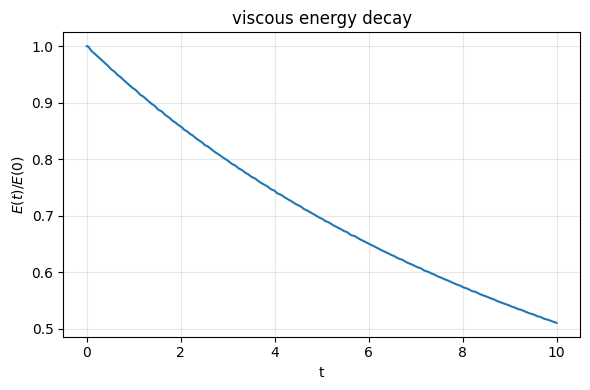

saved wave_carpet_viscous.mp4


In [12]:


# ----------------------------------------------------------------------
# Animation
# ----------------------------------------------------------------------
def animate_solution(X, Y, frames, times, filename="wave_carpet.mp4",
                     stride=2, fps=30):
    """
    3D surface animation ("moving carpet") with displacement-based colours
    and a slowly rotating camera.
    """
    Xs, Ys = X[::stride, ::stride], Y[::stride, ::stride]
    zmax = max(0.6 * np.abs(frames[0]).max(), 1e-6)

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")
    fig.patch.set_facecolor("black")
    ax.set_facecolor("black")

    norm = plt.Normalize(-zmax, zmax)

    def draw(k):
        ax.clear()
        Z = frames[k][::stride, ::stride]
        ax.plot_surface(Xs, Ys, Z, cmap=cm.coolwarm, norm=norm,
                        rstride=1, cstride=1, linewidth=0,
                        antialiased=True, shade=True)
        ax.set_zlim(-zmax, zmax)
        ax.set_xlabel("x", color="w")
        ax.set_ylabel("y", color="w")
        ax.set_title(f"2D wave equation   t = {times[k]:.3f}",
                     color="w", fontsize=13)
        ax.tick_params(colors="w")
        # smooth camera: slow continuous azimuth sweep + gentle elevation
        ax.view_init(elev=42 + 8 * np.sin(2 * np.pi * k / len(frames)),
                     azim=-60 + 0.35 * k)
        return []

    anim = FuncAnimation(fig, draw, frames=len(frames), blit=False)

    try:
        anim.save(filename, writer=FFMpegWriter(fps=fps, bitrate=3000))
        print(f"saved {filename}")
    except Exception as exc:                     # ffmpeg unavailable
        print(f"ffmpeg failed ({exc}); falling back to GIF")
        gif = filename.rsplit(".", 1)[0] + ".gif"
        anim.save(gif, writer=PillowWriter(fps=fps))
        print(f"saved {gif}")
    plt.close(fig)
    return anim


if __name__ == "__main__":
    X, Y, frames, times, energies = simulate(
        N=201, c=1.0, T=10, cfl=0.4, store_every=4,
        nu=2e-4, gamma=0.0, theta=0.5,
    )

    # verification: with nu > 0 the energy must decay monotonically
    plt.figure(figsize=(6, 4))
    plt.plot(times, energies / energies[0])
    plt.xlabel("t")
    plt.ylabel(r"$E(t)/E(0)$")
    plt.title("viscous energy decay")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    animate_solution(X, Y, frames, times,
                     filename="wave_carpet_viscous.mp4")